# Entregable 4 – Deep Learning: Clasificación de Imágenes en CIFAR-100
## Máster en Data Science & AI

---

**Grupo 4**  

*Osvaldo Javier Hernández Vélez*

*Jon Mikel García Zurutuza*

*Jorge Espina Casado*

*Ronal Hernando Cuesta Chaverra*

---

## Índice
1. [Introducción y Objetivos](#1)
2. [Carga y Exploración del Dataset](#2)
3. [Preprocesamiento y Data Augmentation](#3)
4. [Método 1 – Transfer Learning + Fine Tuning](#4)
5. [Método 2 – Red Neuronal desde Cero](#5)
6. [Comparación de Resultados](#6)
7. [Conclusiones](#7)

---

## 1. Introducción y Objetivos <a id='1'></a>

En este entregable se evalúan **dos estrategias distintas** para clasificar imágenes del dataset **CIFAR-100** (100 clases, 60.000 imágenes de 32×32 píxeles):

| Método | Descripción |
|--------|-------------|
| **Método 1** | Comparación de dos redes pre-entrenadas (EfficientNetB0 vs MobileNetV2) → Transfer Learning → Fine Tuning con la mejor |
| **Método 2** | CNN diseñada desde cero con regularización, dropout, batch norm y data augmentation |

El objetivo es analizar el rendimiento de ambos enfoques y determinar cuál resulta más adecuado para este problema concreto.

In [3]:
# Cargamos todas las librerías que necesitamos. Silenciamos warnings y logs
# de TensorFlow para que la salida sea más limpia y fácil de leer.
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, time
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelBinarizer

# Fijamos una semilla para que los resultados sean reproducibles: sin esto,
# los pesos se inicializan distinto cada vez y los números cambian en cada ejecución.
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {keras.__version__}')
print(f'GPUs disponibles   : {len(tf.config.list_physical_devices("GPU"))}')

TensorFlow version : 2.16.2
Keras version      : 3.14.0
GPUs disponibles   : 1


---
## 2. Carga y Exploración del Dataset <a id='2'></a>

**CIFAR-100** tiene 60.000 imágenes de 32×32 píxeles repartidas en 100 categorías: desde manzanas hasta lobos, pasando por camiones, orquídeas o cocodrilos. Es un dataset difícil por dos razones principales: las imágenes son muy pequeñas (poca información por píxel) y hay solo 500 ejemplos por clase para entrenar, lo que obliga a los modelos a generalizar bien en lugar de memorizar.

Antes de ponernos a entrenar, merece la pena echar un vistazo a los datos para hacernos una idea visual de con qué estamos trabajando.

=== CIFAR-100 ===
Train: (50000, 32, 32, 3)  |  dtype: uint8  |  rango: [0, 255]
Test : (10000, 32, 32, 3)  |  etiquetas únicas: 100


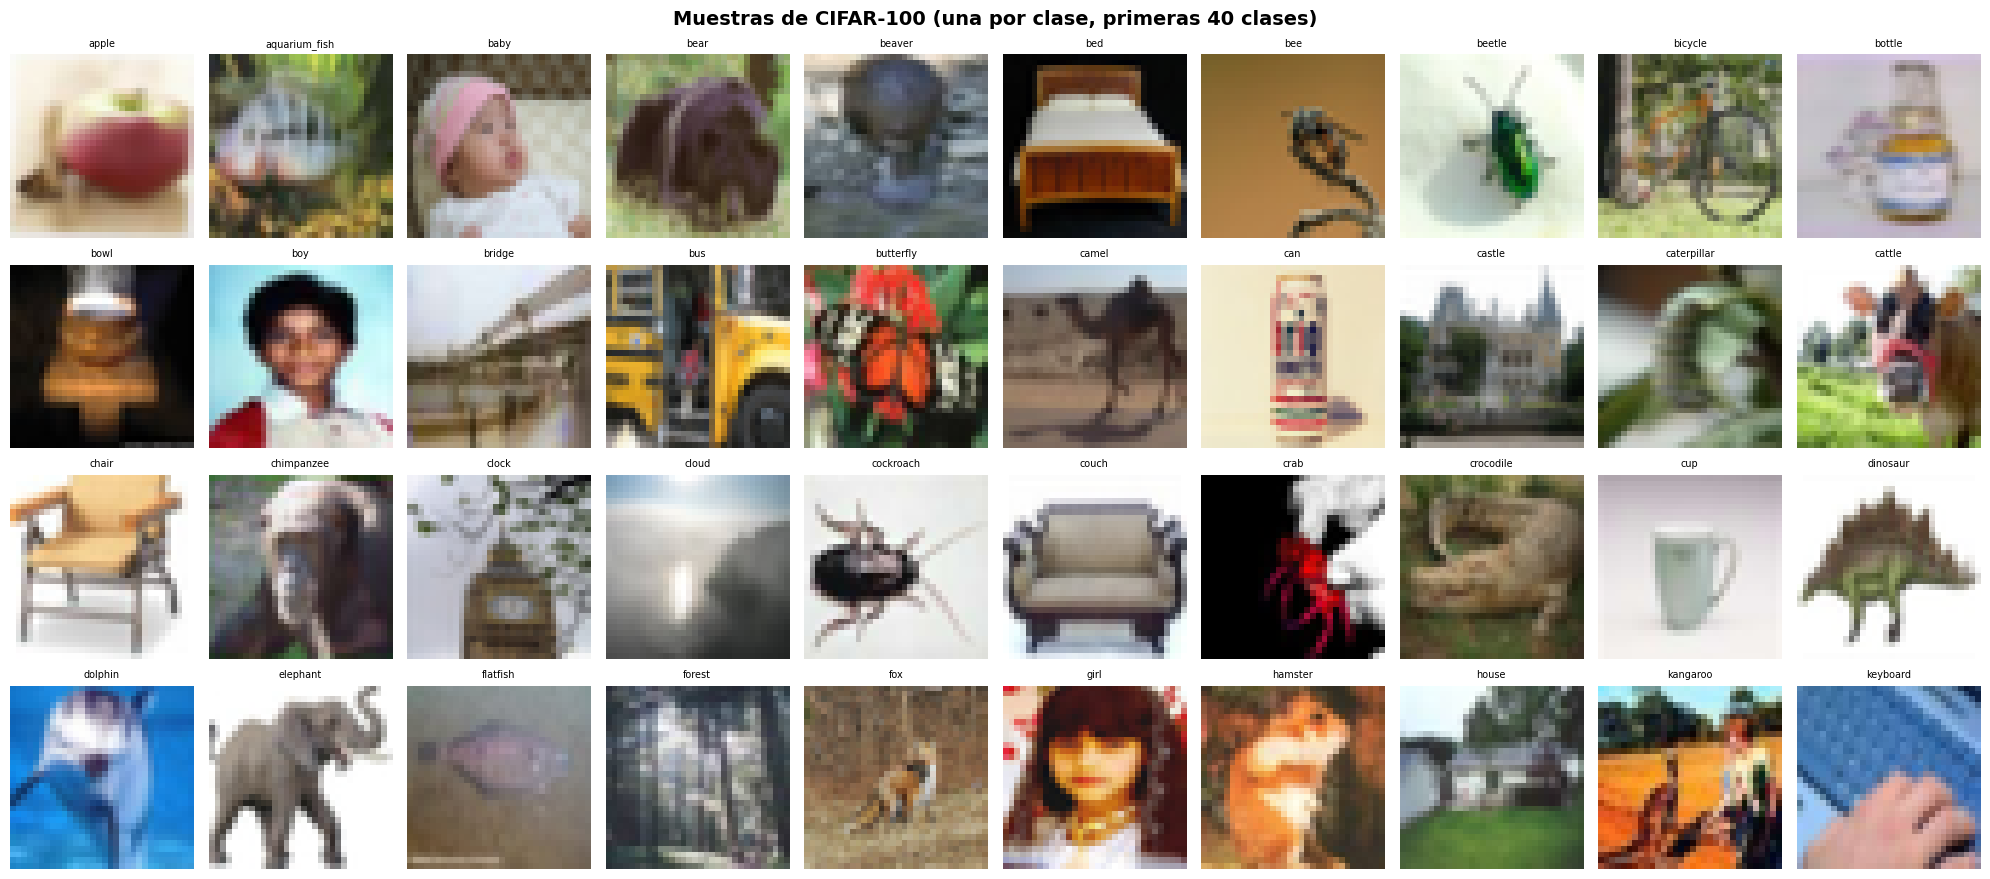

Figura guardada: cifar100_muestras.png


In [4]:
# Cargamos CIFAR-100 directamente desde Keras. Viene listo para usar,
# dividido en train y test, sin necesidad de descargarlo a mano.
from tensorflow.keras.datasets import cifar100

((x_train_raw, y_train_raw), (x_test_raw, y_test_raw)) = cifar100.load_data()

print('=== CIFAR-100 ===')
print(f'Train: {x_train_raw.shape}  |  dtype: {x_train_raw.dtype}  |  rango: [{x_train_raw.min()}, {x_train_raw.max()}]')
print(f'Test : {x_test_raw.shape}  |  etiquetas únicas: {len(np.unique(y_train_raw))}')

# Guardamos los nombres de las 100 clases para poder etiquetarlos en los gráficos.
FINE_LABELS = [
    'apple','aquarium_fish','baby','bear','beaver','bed','bee','beetle','bicycle','bottle',
    'bowl','boy','bridge','bus','butterfly','camel','can','castle','caterpillar','cattle',
    'chair','chimpanzee','clock','cloud','cockroach','couch','crab','crocodile','cup','dinosaur',
    'dolphin','elephant','flatfish','forest','fox','girl','hamster','house','kangaroo','keyboard',
    'lamp','lawn_mower','leopard','lion','lizard','lobster','man','maple_tree','motorcycle','mountain',
    'mouse','mushroom','oak_tree','orange','orchid','otter','palm_tree','pear','pickup_truck','pine_tree',
    'plain','plate','poppy','porcupine','possum','rabbit','raccoon','ray','road','rocket',
    'rose','sea','seal','shark','shrew','skunk','skyscraper','snail','snake','spider',
    'squirrel','streetcar','sunflower','sweet_pepper','table','tank','telephone','television','tiger','tractor',
    'train','trout','tulip','turtle','wardrobe','whale','willow_tree','wolf','woman','worm'
]

# Visualizamos una imagen de cada una de las primeras 40 clases para hacernos
# una idea de con qué tipo de imágenes vamos a trabajar.
fig, axes = plt.subplots(4, 10, figsize=(20, 9))
fig.suptitle('Muestras de CIFAR-100 (una por clase, primeras 40 clases)', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train_raw.flatten() == i)[0][0]
    ax.imshow(x_train_raw[idx])
    ax.set_title(FINE_LABELS[i], fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.savefig('cifar100_muestras.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: cifar100_muestras.png')

---
## 3. Preprocesamiento y Data Augmentation <a id='3'></a>

### 3.1 Normalización y división de los datos

Antes de que la red vea un solo píxel hay que preparar bien los datos. Dos decisiones clave:

**División train / validación / test**

CIFAR-100 no incluye conjunto de validación oficial, así que separamos manualmente el 10% del train (5.000 imágenes) para usarlo de validación durante el entrenamiento. El test (10.000 imágenes) lo reservamos intacto y no lo tocamos hasta la evaluación final — es la única forma de medir el rendimiento real sin hacernos trampas a nosotros mismos.

**Normalización — ¿por qué diferente en cada método?**

Los dos métodos necesitan estrategias distintas por una razón concreta:

- **Método 1 (Transfer Learning):** Cada arquitectura preentrenada tiene su propio preprocesado interno que espera recibir los píxeles en un rango específico (el mismo con el que fue entrenada en ImageNet). Si lo cambiamos, estamos "hablándole en otro idioma" y el modelo rendirá peor. Así que dejamos que cada uno aplique el suyo.
- **Método 2 (CNN desde cero):** Aquí controlamos todo el proceso, así que normalizamos nosotros: dividimos entre 255 para pasar al rango [0,1] y luego estandarizamos con la media y la desviación típica conocidas de CIFAR-100. Importante: estos valores se calculan **solo sobre el train** — usar el test para calcularlos sería filtrar información que no deberíamos ver.

In [ ]:
# Parámetros globales. Los definimos aquí arriba para tenerlos todos en un sitio
# y poder cambiarlos fácilmente sin tener que buscarlos por el notebook.
NUM_CLASSES   = 100
IMG_SIZE_TL   = 96    # CIFAR tiene imágenes 32x32 pero los modelos preentrenados
                      # rinden mejor con imágenes más grandes, así que las escalamos a 96x96
BATCH_SIZE    = 128   # Subimos de 64 a 128 para aprovechar mejor la GPU y entrenar más rápido
EPOCHS_TL_1   = 15   # Épocas para la fase de Feature Extraction (backbone congelado)
EPOCHS_TL_2   = 30   # Épocas para Fine Tuning — el EarlyStopping parará antes si converge
EPOCHS_CUSTOM = 50   # Épocas para la CNN desde cero

from sklearn.model_selection import train_test_split

# CIFAR-100 solo trae train y test, sin validación oficial.
# Separamos un 10% del train (5.000 imágenes) para usarlo como validación.
# El test (10.000 imágenes) lo reservamos intacto para la evaluación final:
# nunca lo usamos durante el entrenamiento para que el resultado sea honesto.
#
#   50.000 train  →  45.000 entrenamiento + 5.000 validación
#   10.000 test   →  solo al final, para medir el rendimiento real

x_tr_raw, x_val_raw, y_tr_raw, y_val_raw = train_test_split(
    x_train_raw, y_train_raw,
    test_size=0.10,
    random_state=SEED,
    stratify=y_train_raw   # así cada clase queda igual de representada en train y val
)

print('=== División del dataset ===')
print(f'  Train final : {x_tr_raw.shape[0]:,} imágenes')
print(f'  Validación  : {x_val_raw.shape[0]:,} imágenes')
print(f'  Test        : {x_test_raw.shape[0]:,} imágenes (solo evaluación final)')

# Normalizamos las imágenes para que los valores de píxel estén centrados en 0.
# Usamos los valores de media y std conocidos de CIFAR-100.
# Importante: estos valores se calcularon sobre el train, nunca usamos el test
# para calcularlos (eso sería hacer trampa).
MEAN = np.array([0.5071, 0.4867, 0.4408])
STD  = np.array([0.2675, 0.2565, 0.2761])

def normalize(x):
    return (x.astype('float32') / 255.0 - MEAN) / STD

x_tr_norm  = normalize(x_tr_raw)
x_val_norm = normalize(x_val_raw)
x_test_norm = normalize(x_test_raw)

# Convertimos las etiquetas a formato one-hot.
# Hacemos fit solo sobre train para no filtrar información del test al codificador.
lb = LabelBinarizer()
y_tr_oh   = lb.fit_transform(y_tr_raw)
y_val_oh  = lb.transform(y_val_raw)
y_test_oh = lb.transform(y_test_raw)
# y_train_oh no se necesita — eliminamos también el codificador para liberar memoria
del lb

print(f'\nNormalización completada:')
print(f'  x_tr_norm  : media={x_tr_norm.mean():.4f}, std={x_tr_norm.std():.4f}')
print(f'  x_val_norm : media={x_val_norm.mean():.4f}, std={x_val_norm.std():.4f}')
print(f'  x_test_norm: media={x_test_norm.mean():.4f}, std={x_test_norm.std():.4f}')

=== División del dataset ===
  Train final : 45,000 imágenes
  Validación  : 5,000 imágenes
  Test        : 10,000 imágenes (solo evaluación final)

Normalización completada:
  x_tr_norm  : media=-0.0002, std=0.9995
  x_val_norm : media=0.0014, std=1.0026
  x_test_norm: media=0.0044, std=1.0033


### 3.2 Data Augmentation

Con solo 500 imágenes por clase el riesgo de sobreajuste es alto: la red podría aprenderse los ejemplos de memoria en lugar de aprender a reconocer el objeto de verdad. El data augmentation lo resuelve mostrándole versiones ligeramente distintas de cada imagen en cada época, como si tuviéramos más datos de los que realmente tenemos.

La clave aquí es ser conservadores. Las imágenes son de 32×32 y ya tienen poca información — transformaciones agresivas (rotaciones grandes, recortes extremos) destruirían los detalles que la red necesita ver para reconocer el objeto. Por eso usamos solo volteo horizontal, giros suaves, zoom ligero y pequeñas variaciones de contraste.

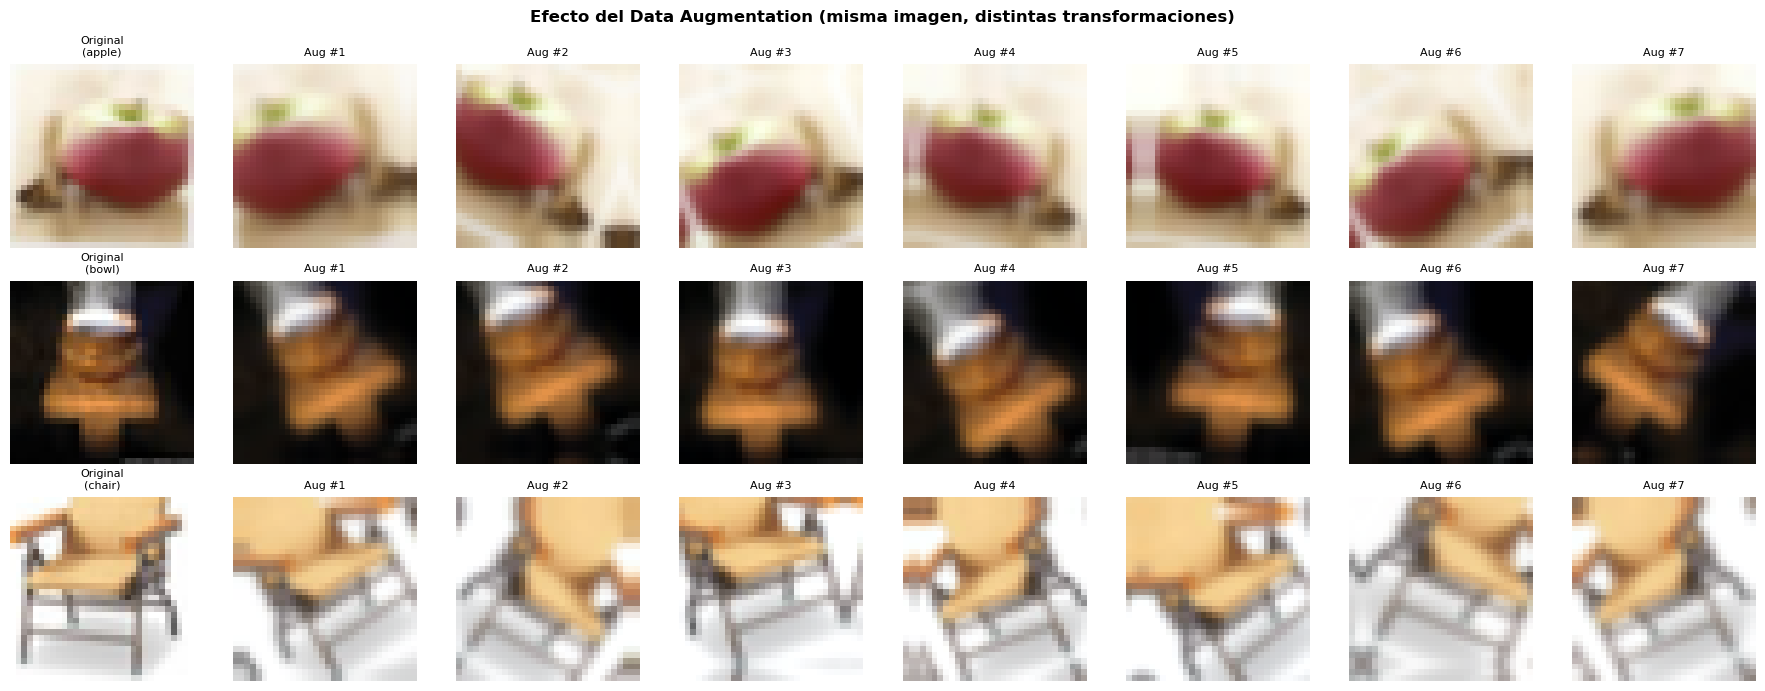

Figura guardada: data_augmentation.png


In [ ]:
# Definimos las transformaciones de data augmentation para el Método 1.La idea es mostrarle a la red versiones ligeramente distintas de cada imagen para que aprenda a reconocer objetos 
# aunque estén girados, desplazados o con diferente brillo. Elegimos transformaciones conservadoras porque las imágenes son muy pequeñas (32x32) y no queremos destruir su información.

data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),       # dar la vuelta — tiene sentido para la mayoría de objetos
    layers.RandomRotation(0.1),            # giro suave, máximo ~36 grados
    layers.RandomZoom(0.1),                # zoom ligero
    layers.RandomTranslation(0.1, 0.1),   # pequeño desplazamiento
    layers.RandomContrast(0.1),            # variación mínima de contraste
], name='data_augmentation')

# Visualizamos el efecto del augmentation para comprobar que las transformaciones tienen sentido y no distorsionan demasiado las imágenes.
fig, axes = plt.subplots(3, 8, figsize=(18, 7))
fig.suptitle('Efecto del Data Augmentation (misma imagen, distintas transformaciones)', 
             fontsize=12, fontweight='bold')

sample_classes = [0, 10, 20]
for row, cls in enumerate(sample_classes):
    sample_idx = np.where(y_train_raw.flatten() == cls)[0][0]
    sample_img = x_train_raw[sample_idx:sample_idx+1].astype('float32')
    
    axes[row, 0].imshow(x_train_raw[sample_idx])
    axes[row, 0].set_title(f'Original\n({FINE_LABELS[cls]})', fontsize=8)
    axes[row, 0].axis('off')
    
    for col in range(1, 8):
        aug = data_augmentation(sample_img, training=True)
        aug_img = np.clip(aug[0].numpy() / 255.0, 0, 1)
        axes[row, col].imshow(aug_img)
        axes[row, col].set_title(f'Aug #{col}', fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('data_augmentation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: data_augmentation.png')

# Ya no necesitamos los arrays originales completos: x_tr_raw/x_val_raw están
# en el split y x_train_raw solo se usó para visualización. Los borramos.
del x_train_raw, y_train_raw

---
## 4. Método 1 – Transfer Learning + Fine Tuning <a id='4'></a>

La idea del Transfer Learning es partir de un modelo que ya sabe ver. EfficientNetB0 y MobileNetV2 han sido entrenados en ImageNet — más de un millón de imágenes — y ya saben detectar bordes, texturas, formas y patrones complejos. En lugar de aprender todo eso desde cero, lo aprovechamos.

El proceso tiene dos fases:

```
Fase 1 – ¿Qué arquitectura va mejor?
  EfficientNetB0  ──►  Backbone congelado  ──►  Solo entrenamos la cabeza  ──►  val_accuracy
  MobileNetV2     ──►  Backbone congelado  ──►  Solo entrenamos la cabeza  ──►  val_accuracy
                                        ↓
                              Ganadora → Fase 2

Fase 2 – Fine Tuning:
  Mejor arquitectura  ──►  Descongelamos las últimas capas  ──►  LR muy pequeño  ──►  Resultado final
```

En la **Fase 1** el backbone queda congelado: la red no toca los pesos preentrenados, solo aprende la cabeza de clasificación nueva. En la **Fase 2** descongelamos las últimas capas para que el modelo se adapte un poco más a las características concretas de CIFAR-100.

**¿Por qué comparar dos arquitecturas antes de hacer Fine Tuning?**

Porque no tiene sentido hacer Fine Tuning de las dos (es caro) si podemos descartar la peor rápido con un entrenamiento corto. Elegimos estas dos porque ambas son ligeras y funcionan bien con recursos limitados:

| Arquitectura | Parámetros | Por qué la elegimos |
|---|---|---|
| **EfficientNetB0** | ~5.3M | Buen balance entre precisión y eficiencia |
| **MobileNetV2** | ~3.4M | Más compacta, diseñada para entornos con recursos limitados |

Como CIFAR-100 tiene imágenes de 32×32 y estos modelos fueron entrenados con imágenes mucho más grandes, las escalamos a 96×96 antes de pasárselas — con el tamaño original rendirían bastante peor.

### 4.1 EfficientNetB0
Preparamos los datasets para el Método 1 (Transfer Learning). Los modelos preentrenados esperan imágenes en rango [0, 255] porque así fueron entrenados en ImageNet — cada uno aplica su propio preprocesado interno.
Por eso usamos los arrays originales (raw) y no los normalizados.
El augmentation solo va al conjunto de entrenamiento, nunca a val ni test.

In [ ]:
# Comenzamos la preparación de los datasets para el Método 1 (Transfer Learning).
def make_tl_dataset(x, y, augment=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((x.astype('float32'), y))
    if augment:
        ds = ds.shuffle(50000, seed=SEED)
        ds = ds.map(lambda img, lbl: (data_augmentation(img[None], training=True)[0], lbl),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

y_tr_oh_tl  = keras.utils.to_categorical(y_tr_raw,   NUM_CLASSES)
y_val_oh_tl = keras.utils.to_categorical(y_val_raw,  NUM_CLASSES)

ds_train_tl = make_tl_dataset(x_tr_raw,   y_tr_oh_tl,  augment=True)
ds_val_tl   = make_tl_dataset(x_val_raw,  y_val_oh_tl, augment=False)
ds_test_tl  = make_tl_dataset(x_test_raw, y_test_oh,   augment=False)

print(f'Batches de train : {len(ds_train_tl)}')
print(f'Batches de val   : {len(ds_val_tl)}')
print(f'Batches de test  : {len(ds_test_tl)} (solo evaluación final)')

# Los arrays y etiquetas ya están empaquetados dentro de los datasets de TensorFlow.
# A partir de aquí el pipeline los gestiona, así que liberamos los arrays sueltos.
del y_tr_raw, y_val_raw, y_tr_oh_tl, y_val_oh_tl

Batches de train : 352
Batches de val   : 40
Batches de test  : 79 (solo evaluación final)


In [ ]:
# Los arrays originales ya están dentro de los datasets de TensorFlow, así que ya no los necesitamos sueltos en memoria. Los borramos para liberar RAM.
# Conservamos x_test_raw porque lo necesitaremos al final para visualizar las imágenes que el modelo clasifica mal.
del x_tr_raw, x_val_raw

In [ ]:
# Definimos los tres callbacks que usaremos en todos los entrenamientos. Los agrupamos en una función para no repetir el mismo bloque de código cada vez.

# EarlyStopping: para el entrenamiento si la accuracy de validación no mejora en N épocas. Así evitamos sobreajuste y no perdemos tiempo entrenando de más.
# Restaura automáticamente los pesos del mejor momento.

# ReduceLROnPlateau: si el modelo se atasca, reduce el learning rate a la mitad.
#   Con un paso más pequeño a veces consigue salir de donde estaba bloqueado.

# ModelCheckpoint: guarda el mejor modelo en disco durante el entrenamiento, por si algo falla o queremos recuperar los mejores pesos más adelante.
def get_callbacks(name, patience_es=8, patience_lr=4):
    return [
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=patience_es,
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=patience_lr,
            min_lr=1e-7, verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=f'{name}_best.keras',
            monitor='val_accuracy', save_best_only=True, verbose=0
        )
    ]

### 4.2 EfficientNetB0

Empezamos con EfficientNetB0. El backbone queda completamente congelado — solo entrenamos la cabeza de clasificación que hemos añadido encima. El objetivo de esta fase no es sacar el mejor resultado posible, sino comparar qué arquitectura aprende mejor sobre CIFAR-100 antes de invertir tiempo en el Fine Tuning.

In [ ]:
# Creamos una función genérica para construir modelos de Transfer Learning. La hacemos genérica para probar EfficientNetB0 y MobileNetV2 con el mismo
# código y comparar en igualdad de condiciones.

# La arquitectura tiene dos partes:
#   1. El backbone preentrenado que actúa como extractor de características.
#      En la primera fase lo dejamos congelado para no modificar lo que aprendió.
#   2. Nuestra cabeza de clasificación encima, que entrenamos desde cero
#      para adaptarla a las 100 clases de CIFAR-100.

# Como CIFAR tiene imágenes de 32x32 y los modelos fueron entrenados con imágenes mucho más grandes, escalamos la entrada a 96x96.
def build_transfer_model(backbone_name='efficientnetb0', trainable_base=False, fine_tune_at=None):
    inputs = keras.Input(shape=(32, 32, 3), name='input_32x32')
    x = layers.Resizing(IMG_SIZE_TL, IMG_SIZE_TL, name='upscaling')(inputs)
    
    # Cada modelo tiene su propio preprocesado que aplicamos antes del backbone.
    if backbone_name == 'efficientnetb0':
        x = keras.applications.efficientnet.preprocess_input(x)
        base_model = EfficientNetB0(
            include_top=False, weights='imagenet',
            input_tensor=x, pooling='avg'
        )
    elif backbone_name == 'mobilenetv2':
        x = keras.applications.mobilenet_v2.preprocess_input(x)
        base_model = MobileNetV2(
            include_top=False, weights='imagenet',
            input_tensor=x, pooling='avg'
        )
    
    base_model.trainable = trainable_base
    
    # En Fine Tuning descongelamos solo las últimas capas del backbone.
    # No descongelamos todo porque las primeras capas detectan patrones básicos (bordes, texturas) útiles para cualquier dataset — no queremos perderlos.
    # Las BatchNorm siempre se quedan congeladas: en modo entrenamiento actualizan sus estadísticas y pueden desestabilizar el proceso con datos muy distintos.
    if fine_tune_at is not None:
        base_model.trainable = True
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False
        for layer in base_model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
    
    # Nuestra cabeza de clasificación: BatchNorm para estabilizar la entrada, capa densa para combinar features, Dropout para reducir sobreajuste, y softmax final para obtener 
    # probabilidades sobre las 100 clases.
    features = base_model.output
    x = layers.BatchNormalization(name='head_bn')(features)
    x = layers.Dense(512, name='head_dense1')(x)
    x = layers.BatchNormalization(name='head_bn2')(x)
    x = layers.Activation('swish', name='head_act')(x)
    x = layers.Dropout(0.4, name='head_dropout')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    trainable = sum(np.prod(v.shape) for v in model.trainable_weights)
    total     = sum(np.prod(v.shape) for v in model.weights)
    print(f'  Backbone              : {backbone_name}')
    print(f'  Parámetros totales    : {total:,}')
    print(f'  Parámetros entrenables: {trainable:,}  ({100*trainable/total:.1f}%)')
    
    return model, base_model


# Entrenamos primero EfficientNetB0 con el backbone congelado. El objetivo aquí no es el resultado final sino ver qué arquitectura aprende mejor sobre CIFAR-100 antes de hacer Fine Tuning.
print('=== ARQUITECTURA 1: EfficientNetB0 – Feature Extraction ===')
model_eff, base_eff = build_transfer_model('efficientnetb0', trainable_base=False)

model_eff.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')]
)

t0 = time.time()
hist_eff = model_eff.fit(
    ds_train_tl, validation_data=ds_val_tl,
    epochs=EPOCHS_TL_1,
    callbacks=get_callbacks('eff_fe'),
    verbose=1
)
t_eff = time.time() - t0
loss_eff_fe, acc_eff_fe, _ = model_eff.evaluate(ds_val_tl, verbose=0)
print(f'\nEfficientNetB0 – Val Accuracy: {acc_eff_fe*100:.2f}%  |  {t_eff/60:.1f} min')

=== ARQUITECTURA 1: EfficientNetB0 – Feature Extraction ===
  Backbone              : efficientnetb0
  Parámetros totales    : 4,763,911.0
  Parámetros entrenables: 710,756  (14.9%)
Epoch 1/15


2026-04-27 19:34:03.610793: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.2552 - loss: 3.2150 - top5_acc: 0.5100

2026-04-27 19:35:16.169915: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


352/352 ━━━━━━━━━━━━━━━━━━━━ 87s 233ms/step - accuracy: 0.3378 - loss: 2.7064 - top5_acc: 0.6287 - val_accuracy: 0.5766 - val_loss: 1.6062 - val_top5_acc: 0.8550 - learning_rate: 0.0010
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.4386 - loss: 2.1556 - top5_acc: 0.7430

...

352/352 ━━━━━━━━━━━━━━━━━━━━ 122s 346ms/step - accuracy: 0.5417 - loss: 1.6756 - top5_acc: 0.8280 - val_accuracy: 0.6322 - val_loss: 1.3393 - val_top5_acc: 0.8844 - learning_rate: 0.0010
Epoch 14/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.5459 - loss: 1.6534 - top5_acc: 0.8349

2026-04-27 19:58:51.073019: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.



Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
352/352 ━━━━━━━━━━━━━━━━━━━━ 109s 309ms/step - accuracy: 0.5409 - loss: 1.6738 - top5_acc: 0.8317 - val_accuracy: 0.6268 - val_loss: 1.3519 - val_top5_acc: 0.8826 - learning_rate: 0.0010
Epoch 15/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.5636 - loss: 1.5927 - top5_acc: 0.8419

2026-04-27 20:00:37.772219: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


352/352 ━━━━━━━━━━━━━━━━━━━━ 106s 302ms/step - accuracy: 0.5599 - loss: 1.6049 - top5_acc: 0.8396 - val_accuracy: 0.6300 - val_loss: 1.3379 - val_top5_acc: 0.8828 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 13.

EfficientNetB0 – Val Accuracy: 63.22%  |  26.7 min


### 4.3 MobileNetV2

Mismo proceso con MobileNetV2. Usamos exactamente las mismas condiciones: mismos datos, mismo número de épocas, mismos callbacks. Así la comparación es justa y la diferencia de resultados refleja solo la arquitectura, no otras variables.

In [ ]:
# Hacemos lo mismo con MobileNetV2 para poder comparar en igualdad de condiciones: mismos datos, mismo número de épocas, mismos callbacks.
print('=== ARQUITECTURA 2: MobileNetV2 – Feature Extraction ===')
model_mob, base_mob = build_transfer_model('mobilenetv2', trainable_base=False)

model_mob.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')]
)

t0 = time.time()
hist_mob = model_mob.fit(
    ds_train_tl, validation_data=ds_val_tl,
    epochs=EPOCHS_TL_1,
    callbacks=get_callbacks('mob_fe'),
    verbose=1
)
t_mob = time.time() - t0
loss_mob_fe, acc_mob_fe, _ = model_mob.evaluate(ds_val_tl, verbose=0)
print(f'\nMobileNetV2 – Val Accuracy: {acc_mob_fe*100:.2f}%  |  {t_mob/60:.1f} min')

=== ARQUITECTURA 2: MobileNetV2 – Feature Extraction ===
  Backbone              : mobilenetv2
  Parámetros totales    : 2,972,324
  Parámetros entrenables: 710,756  (23.9%)
Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.2055 - loss: 3.4621 - top5_acc: 0.4436

2026-04-27 20:02:18.005014: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


352/352 ━━━━━━━━━━━━━━━━━━━━ 97s 266ms/step - accuracy: 0.2743 - loss: 3.0009 - top5_acc: 0.5581 - val_accuracy: 0.4744 - val_loss: 1.9378 - val_top5_acc: 0.7948 - learning_rate: 0.0010
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.3657 - loss: 2.5068 - top5_acc: 0.6710

2026-04-27 20:04:00.799548: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


352/352 ━━━━━━━━━━━━━━━━━━━━ 98s 278ms/step - accuracy: 0.3656 - loss: 2.4956 - top5_acc: 0.6732 - val_accuracy: 0.5086 - val_loss: 1.8069 - val_top5_acc: 0.8176 - learning_rate: 0.0010
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.3850 - loss: 2.3821 - top5_acc: 0.6968

...

352/352 ━━━━━━━━━━━━━━━━━━━━ 91s 257ms/step - accuracy: 0.4413 - loss: 2.1109 - top5_acc: 0.7486 - val_accuracy: 0.5396 - val_loss: 1.6557 - val_top5_acc: 0.8420 - learning_rate: 0.0010
Epoch 14/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.4450 - loss: 2.0825 - top5_acc: 0.7529

2026-04-27 20:21:47.070978: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


352/352 ━━━━━━━━━━━━━━━━━━━━ 96s 272ms/step - accuracy: 0.4432 - loss: 2.0970 - top5_acc: 0.7497 - val_accuracy: 0.5390 - val_loss: 1.6548 - val_top5_acc: 0.8418 - learning_rate: 0.0010
Epoch 15/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.4550 - loss: 2.0444 - top5_acc: 0.7615

2026-04-27 20:23:26.514316: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.



Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
352/352 ━━━━━━━━━━━━━━━━━━━━ 99s 281ms/step - accuracy: 0.4514 - loss: 2.0660 - top5_acc: 0.7571 - val_accuracy: 0.5456 - val_loss: 1.6496 - val_top5_acc: 0.8440 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 11.

MobileNetV2 – Val Accuracy: 54.72%  |  22.7 min


### 4.4 Comparación EfficientNetB0 vs MobileNetV2

Con los dos entrenamientos completados, comparamos los resultados y elegimos automáticamente la arquitectura ganadora. El modelo que pierda lo eliminaremos de memoria antes de continuar — ocupa unos 500 MB que necesitaremos para el Fine Tuning.

=== COMPARACIÓN: EfficientNetB0 vs MobileNetV2 (Feature Extraction) ===
  EfficientNetB0  →  Val Accuracy: 63.22%  |  Loss: 1.3393
  MobileNetV2     →  Val Accuracy: 54.72%  |  Loss: 1.6458


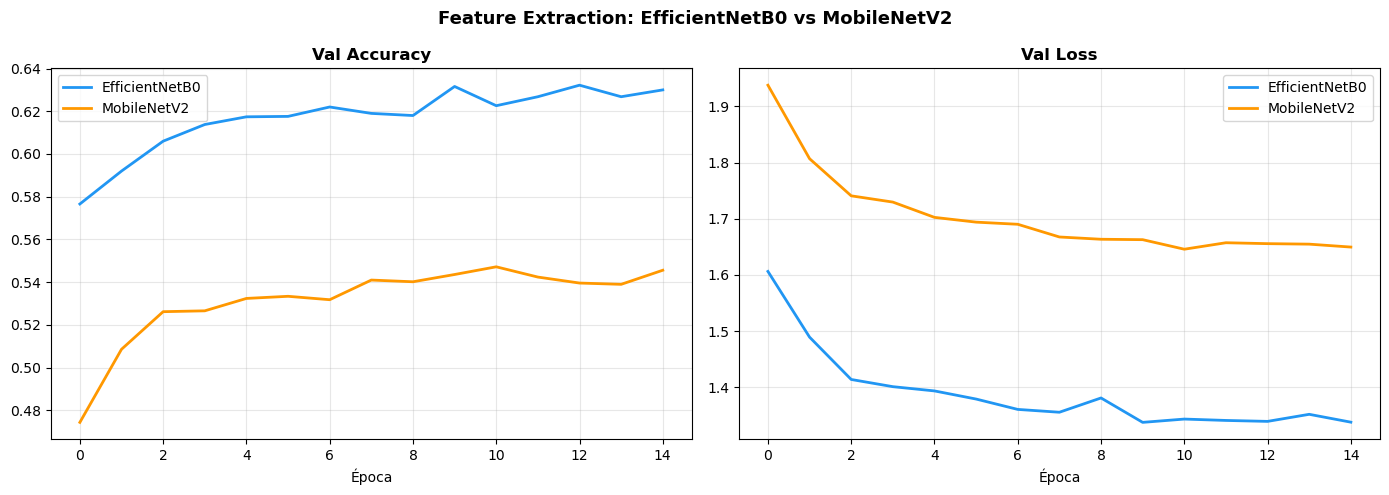


→ Arquitectura seleccionada para Fine Tuning: EfficientNetB0


In [ ]:
# Comparamos los resultados y elegimos la arquitectura ganadora automáticamente, para que el notebook funcione sin importar cuál de las dos haya ganado.
print('=== COMPARACIÓN: EfficientNetB0 vs MobileNetV2 (Feature Extraction) ===')
print(f'  EfficientNetB0  →  Val Accuracy: {acc_eff_fe*100:.2f}%  |  Loss: {loss_eff_fe:.4f}')
print(f'  MobileNetV2     →  Val Accuracy: {acc_mob_fe*100:.2f}%  |  Loss: {loss_mob_fe:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Extraction: EfficientNetB0 vs MobileNetV2', fontsize=13, fontweight='bold')

for ax, (key, title) in zip(axes, [('val_accuracy', 'Val Accuracy'), ('val_loss', 'Val Loss')]):
    ax.plot(hist_eff.history[key], label='EfficientNetB0', color='#2196F3', linewidth=2)
    ax.plot(hist_mob.history[key], label='MobileNetV2',    color='#FF9800', linewidth=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Época'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_arquitecturas.png', dpi=120, bbox_inches='tight')
plt.show()

# El ganador pasa a Fine Tuning. El perdedor lo eliminaremos justo después para recuperar la memoria que ocupa (~500 MB).
if acc_eff_fe >= acc_mob_fe:
    model_tl   = model_eff
    base_model = base_eff
    winner_name = 'EfficientNetB0'
    hist_tl1 = hist_eff
    t_tl1 = t_eff
else:
    model_tl   = model_mob
    base_model = base_mob
    winner_name = 'MobileNetV2'
    hist_tl1 = hist_mob
    t_tl1 = t_mob

print(f'\n→ Arquitectura seleccionada para Fine Tuning: {winner_name}')

In [13]:
# El modelo perdedor ya no lo necesitamos y ocupa unos 500 MB en memoria.
# Lo eliminamos antes del Fine Tuning para tener más RAM disponible.
if winner_name == 'EfficientNetB0':
    del model_mob, base_mob
else:
    del model_eff, base_eff

### 4.5 Fine Tuning

Ahora que sabemos cuál arquitectura funciona mejor, vamos un paso más allá: descongelamos las últimas capas del backbone para que se ajusten a las características concretas de CIFAR-100. No descongelamos todo — las primeras capas detectan bordes y texturas básicas útiles para cualquier dataset, no queremos perder eso. Solo tocamos las capas más altas, que aprenden patrones más específicos.



In [14]:
# Ahora descongelamos las últimas capas del backbone para que se adapten a las características de CIFAR-100. No descongelamos todo porque las primeras
# capas ya saben detectar bordes y texturas básicas — eso nos sirve igual. Descongelamos las últimas 30 capas: suficiente para adaptarse sin perder lo aprendido en ImageNet.
print(f'=== FASE 2: Fine Tuning – {winner_name} ===')
print(f'Capas del backbone: {len(base_model.layers)}')

FINE_TUNE_AT = len(base_model.layers) - 30

base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Las BatchNorm siempre se quedan congeladas aunque estén en la zona descongelada. Si las dejamos en modo entrenamiento pueden desestabilizar el proceso porque
# CIFAR tiene características muy distintas a ImageNet.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_ft = sum(np.prod(v.shape) for v in model_tl.trainable_weights)
total_ft     = sum(np.prod(v.shape) for v in model_tl.weights)
print(f'Parámetros entrenables en Fine Tuning: {trainable_ft:,} ({100*trainable_ft/total_ft:.1f}%)')

# Usamos un learning rate mucho más pequeño que en la fase anterior (1e-4 vs 1e-3). Si usáramos el mismo haríamos cambios demasiado grandes en los pesos preentrenados
# y perderíamos lo que el modelo ya sabe hacer.
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')]
)

t0 = time.time()
hist_tl2 = model_tl.fit(
    ds_train_tl,
    validation_data=ds_val_tl,
    epochs=EPOCHS_TL_2,
    callbacks=get_callbacks('tl_fase2', patience_es=10),
    verbose=1
)
t_tl2 = time.time() - t0
print(f'\nFase 2 completada en {t_tl2/60:.1f} minutos')

=== FASE 2: Fine Tuning – EfficientNetB0 ===
Capas del backbone: 240
Parámetros entrenables en Fine Tuning: 2,194,116 (46.1%)
Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.5637 - loss: 1.5769 - top5_acc: 0.8450

2026-04-27 20:26:16.474185: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


352/352 ━━━━━━━━━━━━━━━━━━━━ 168s 450ms/step - accuracy: 0.5757 - loss: 1.5252 - top5_acc: 0.8536 - val_accuracy: 0.6532 - val_loss: 1.2298 - val_top5_acc: 0.8978 - learning_rate: 1.0000e-04
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.5984 - loss: 1.4313 - top5_acc: 0.8660

2026-04-27 20:28:45.860247: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


352/352 ━━━━━━━━━━━━━━━━━━━━ 144s 409ms/step - accuracy: 0.5996 - loss: 1.4223 - top5_acc: 0.8702 - val_accuracy: 0.6606 - val_loss: 1.1833 - val_top5_acc: 0.9054 - learning_rate: 1.0000e-04
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.6200 - loss: 1.3463 - top5_acc: 0.8820

...

352/352 ━━━━━━━━━━━━━━━━━━━━ 196s 555ms/step - accuracy: 0.7726 - loss: 0.7608 - top5_acc: 0.9568 - val_accuracy: 0.7020 - val_loss: 1.0854 - val_top5_acc: 0.9198 - learning_rate: 2.5000e-05
Epoch 29/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.7764 - loss: 0.7581 - top5_acc: 0.9586

2026-04-27 21:39:34.189117: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


352/352 ━━━━━━━━━━━━━━━━━━━━ 190s 539ms/step - accuracy: 0.7755 - loss: 0.7550 - top5_acc: 0.9587 - val_accuracy: 0.7020 - val_loss: 1.0877 - val_top5_acc: 0.9210 - learning_rate: 2.5000e-05
Epoch 30/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.7788 - loss: 0.7393 - top5_acc: 0.9591

2026-04-27 21:42:48.535379: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.



Epoch 30: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
352/352 ━━━━━━━━━━━━━━━━━━━━ 194s 551ms/step - accuracy: 0.7763 - loss: 0.7479 - top5_acc: 0.9593 - val_accuracy: 0.7020 - val_loss: 1.0837 - val_top5_acc: 0.9204 - learning_rate: 2.5000e-05
Restoring model weights from the end of the best epoch: 26.

Fase 2 completada en 79.2 minutos


### 4.6 Evaluación final sobre Test

Llega el momento de la verdad. Evaluamos sobre el test set, que el modelo no ha visto en ningún momento durante el entrenamiento ni la validación. Este número es el que refleja el rendimiento real del modelo — todo lo anterior ha sido preparación.

=== Resultados finales – Método 1 (Transfer Learning + Fine Tuning) ===
  [Evaluado sobre test set, no visto durante entrenamiento]
  Top-1 Accuracy : 69.83%
  Top-5 Accuracy : 92.45%
  Loss           : 1.0821
  Tiempo total   : 105.9 min


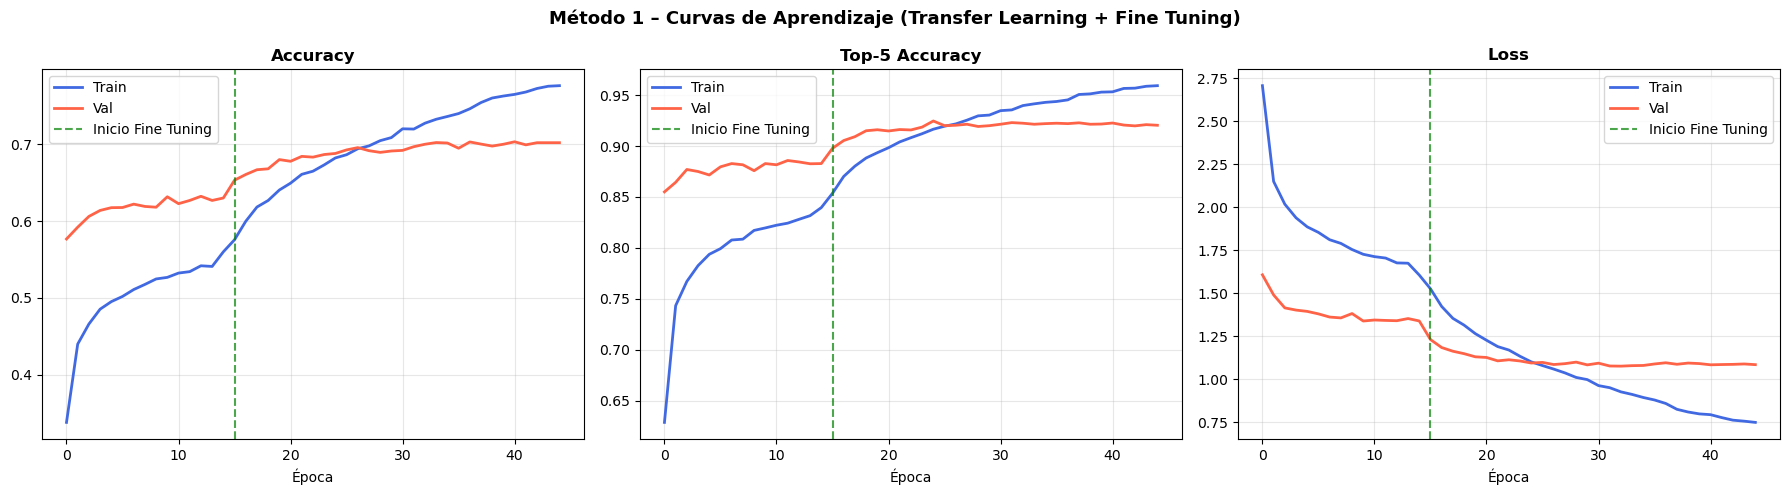

Figura guardada: curvas_metodo1.png


In [15]:
# Evaluamos sobre el test set, que no ha visto en ningún momento durante el entrenamiento. Este es el número que representa el rendimiento real del modelo.
loss_tl2, acc_tl2, top5_tl2 = model_tl.evaluate(ds_test_tl, verbose=0)
print(f'=== Resultados finales – Método 1 (Transfer Learning + Fine Tuning) ===')
print(f'  [Evaluado sobre test set, no visto durante entrenamiento]')
print(f'  Top-1 Accuracy : {acc_tl2*100:.2f}%')
print(f'  Top-5 Accuracy : {top5_tl2*100:.2f}%')
print(f'  Loss           : {loss_tl2:.4f}')
print(f'  Tiempo total   : {(t_tl1+t_tl2)/60:.1f} min')

# Unimos los historiales de las dos fases para dibujar las curvas de aprendizaje completas en una sola gráfica. La línea verde marcará dónde empieza el Fine Tuning.
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

hist_tl_combined = combine_histories(hist_tl1, hist_tl2)
split_epoch = len(hist_tl1.history['accuracy'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Método 1 – Curvas de Aprendizaje (Transfer Learning + Fine Tuning)', 
             fontsize=13, fontweight='bold')

metrics = [('accuracy', 'val_accuracy', 'Accuracy'), 
           ('top5_acc', 'val_top5_acc', 'Top-5 Accuracy'),
           ('loss', 'val_loss', 'Loss')]

for ax, (train_key, val_key, title) in zip(axes, metrics):
    ax.plot(hist_tl_combined[train_key], label='Train', color='royalblue', linewidth=2)
    ax.plot(hist_tl_combined[val_key],   label='Val',   color='tomato',    linewidth=2)
    ax.axvline(split_epoch, color='green', linestyle='--', alpha=0.7, label='Inicio Fine Tuning')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Época'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_metodo1.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: curvas_metodo1.png')

---
## 5. Método 2 – Red Neuronal desde Cero <a id='5'></a>

Aquí no partimos de ningún modelo preentrenado: diseñamos y entrenamos nuestra propia red desde cero. 



**Técnicas aplicadas — ¿por qué cada una?**

| Técnica | Dónde | Por qué |
|---------|-------|---------|
| **Batch Normalization** | Tras cada convolución | Estabiliza el entrenamiento y permite usar learning rates más altos |
| **Dropout** | Tras las capas densas | Fuerza a la red a no depender de neuronas concretas, reduce sobreajuste |
| **Regularización L2** | En capas densas | Penaliza pesos muy grandes, empuja la red hacia soluciones más simples |
| **Data Augmentation** | En el pipeline de datos | Expande artificialmente el conjunto de entrenamiento |
| **Cosine Decay LR** | Scheduler del optimizador | LR alto al principio para aprender rápido, bajada suave al final para refinar |
| **Conexiones residuales** | Bloques ResNet | Permiten entrenar redes profundas sin degradación del gradiente |

**Arquitectura:**
```
Input (32×32×3) → [Stem] → [ResBlock×3, 64 filtros] → [ResBlock×3, 128 filtros] → [ResBlock×3, 256 filtros] → [GAP + Dense] → Output (100)
```

### 5.1 Iniciamos construcción Modelo desde cero

In [ ]:
# Construimos nuestra propia red desde cero sin usar modelos preentrenados.
# Optamos por ResNet porque las conexiones residuales permiten entrenar redes más profundas sin que el gradiente desaparezca.

def conv_bn_act(x, filters, kernel_size=3, strides=1, activation='swish', name_prefix=''):
    # Bloque básico: convolución → normalización por lotes → activación.
    # Ponemos BatchNorm antes de la activación porque estabiliza el entrenamiento.
    # L2 penaliza pesos muy grandes para reducir el sobreajuste.
    x = layers.Conv2D(
        filters, kernel_size, strides=strides, padding='same', use_bias=False,
        kernel_initializer='he_uniform',
        kernel_regularizer=regularizers.l2(1e-4),
        name=f'{name_prefix}_conv' if name_prefix else None
    )(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn' if name_prefix else None)(x)
    x = layers.Activation(activation, name=f'{name_prefix}_act' if name_prefix else None)(x)
    return x


def residual_block(x, filters, strides=1, downsample=False, name='res'):
    # Bloque residual: además de la ruta principal hay un "atajo" que suma la entrada directamente a la salida. Esto permite que el gradiente fluya
    # sin obstáculos y hace posible entrenar redes más profundas.
    shortcut = x
    
    x = conv_bn_act(x, filters, 3, strides=strides, name_prefix=f'{name}_1')
    x = layers.Conv2D(
        filters, 3, padding='same', use_bias=False,
        kernel_initializer='he_uniform',
        kernel_regularizer=regularizers.l2(1e-4),
        name=f'{name}_2_conv'
    )(x)
    x = layers.BatchNormalization(name=f'{name}_2_bn')(x)
    
    # Si cambia el número de filtros o el tamaño espacial, ajustamos el atajo para que las dimensiones coincidan al sumar.
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(
            filters, 1, strides=strides, padding='same', use_bias=False,
            kernel_initializer='he_uniform',
            name=f'{name}_shortcut_conv'
        )(shortcut)
        shortcut = layers.BatchNormalization(name=f'{name}_shortcut_bn')(shortcut)
    
    x = layers.Add(name=f'{name}_add')([x, shortcut])
    x = layers.Activation('swish', name=f'{name}_out')(x)
    return x


def build_custom_cnn():
    inputs = keras.Input(shape=(32, 32, 3), name='input')
    
    # El augmentation se aplica en el pipeline de datos antes de llegar aquí, así que empezamos directamente con la arquitectura.
    # Primer bloque para extraer características básicas de la imagen.
    x = conv_bn_act(inputs, 64, kernel_size=3, name_prefix='stem')
    
    # Grupo 1: aprendemos patrones simples con 64 filtros.
    x = residual_block(x, 64,  name='g1_b1')
    x = residual_block(x, 64,  name='g1_b2')
    x = residual_block(x, 64,  name='g1_b3')
    
    # Grupo 2: doblamos filtros y reducimos el tamaño espacial a la mitad.
    # Así aprendemos patrones más complejos sin que la red sea demasiado costosa.
    x = residual_block(x, 128, strides=2, downsample=True, name='g2_b1')
    x = residual_block(x, 128, name='g2_b2')
    x = residual_block(x, 128, name='g2_b3')
    x = layers.Dropout(0.1, name='g2_drop')(x)
    
    # Grupo 3: volvemos a doblar filtros. Patrones de alto nivel.
    x = residual_block(x, 256, strides=2, downsample=True, name='g3_b1')
    x = residual_block(x, 256, name='g3_b2')
    x = residual_block(x, 256, name='g3_b3')
    x = layers.Dropout(0.2, name='g3_drop')(x)
    
    # No añadimos un cuarto grupo de 512 filtros: con imágenes 32x32, tras el Grupo 3 el mapa espacial ya es 4x4. Más profundidad no aportaría información
    # útil y triplicaría el tiempo de entrenamiento.
    
    # Cabeza de clasificación: GlobalAveragePooling para colapsar el mapa espacial,capa densa con regularización y Dropout antes de la predicción final.
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(
        256, use_bias=False,
        kernel_regularizer=regularizers.l2(1e-4),
        name='head_dense1'
    )(x)
    x = layers.BatchNormalization(name='head_bn')(x)
    x = layers.Activation('swish', name='head_act')(x)
    x = layers.Dropout(0.4, name='head_dropout')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs, name='CustomResNet_CIFAR100')
    return model


model_custom = build_custom_cnn()

total_custom = sum(np.prod(v.shape) for v in model_custom.weights)
print(f'\n=== CustomResNet – Resumen ===')
print(f'Total de parámetros: {total_custom:,}')
model_custom.summary(line_length=100)


=== CustomResNet – Resumen ===
Total de parámetros: 4,423,716


Model: "CustomResNet_CIFAR100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)          │ (None, 32, 32, 3)       │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stem_conv (Conv2D)          │ (None, 32, 32, 64)      │          1,728 │ input[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stem_bn                     │ (None, 32, 32, 64)      │            256 │ stem_conv[0][0]         │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stem_act (Activation)       │ (None, 32, 32, 64)      │              0 │ stem_bn[0][0]           │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ g1_b1_1_conv (Conv2D)       │ (None, 32, 32, 64)      │         36,864 │ stem_act[0][0]          │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ g1_b1_1_bn                  │ (None, 32, 32, 64)      │            256 │ g1_b1_1_conv[0][0]      │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ g1_b1_1_act (Activation)    │ (None, 32, 32, 64)      │              0 │ g1_b1_1_bn[0][0]        │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ g1_b1_2_conv (Conv2D)       │ (None, 32, 32, 64)      │         36,864 │ g1_b1_1_act[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ g1_b1_2_bn                  │ (None, 32, 32, 64)      │            256 │ g1_b1_2_conv[0][0]      │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ g1_b1_add (Add)             │ (None, 32, 32, 64)      │              0 │ g1_b1_2_bn[0][0],       │
│                             │                         │                │ stem_act[0][0]          │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ g1_b1_out (Activation)      │ (None, 32, 32, 64)      │              0 │ g1_b1_add[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ g1_b2_1_conv (Conv2D)       │ (None, 32, 32, 64)      │         36,864 │ g1_b1_out[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ g1_b2_1_bn                  │ (None, 32, 32, 64)      │            256 │ g1_b2_1_conv[0][0]      │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ g1_b2_1_act (Activation)    │ (None, 32, 32, 64)      │              0 │ g1_b2_1_bn[0][0]        │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ g1_b2_2_conv (Conv2D)       │ (None, 32, 32, 64)      │         36,864 │ g1_b2_1_act[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ g1_b2_2_bn                  │ (None, 32, 32, 64)      │            256 │ g1_b2_2_conv[0][0]      │
│ (BatchNormalization)        │                         │    

 Total params: 4,423,716 (16.88 MB)

 Trainable params: 4,416,932 (16.85 MB)

 Non-trainable params: 6,784 (26.50 KB)

### 5.2 Preparamos datos Método 2

Batches de train : 352
Batches de val   : 40
Batches de test  : 79 (solo evaluación final)


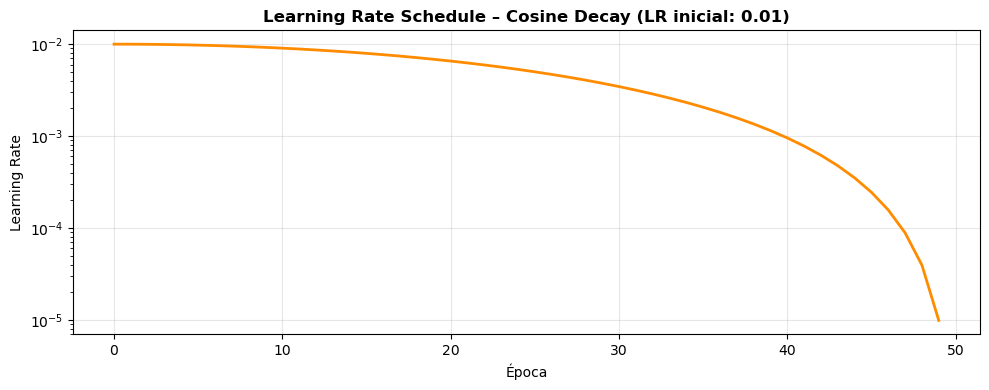

In [17]:
# Preparamos los datos para el Método 2. Aquí trabajamos con imágenes ya normalizadas, así que el augmentation lo aplicaremos manualmente dentro del pipeline de 
# TensorFlow, no como una capa dentro del modelo como en el Método 1.

def augment_normalized(image, label):
    # Transformaciones suaves: volteo, pequeño recorte aleatorio, y ligeras variaciones de brillo y contraste. Todo muy conservador porque las
    # imágenes son pequeñas y no queremos destruir su información.
    image = tf.image.random_flip_left_right(image)
    image = tf.pad(image, [[4, 4], [4, 4], [0, 0]], mode='REFLECT')
    image = tf.image.random_crop(image, size=[32, 32, 3])
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, label

# Augmentation solo en train. Val y test siempre con imágenes originales.
ds_train_custom = tf.data.Dataset.from_tensor_slices(
    (x_tr_norm.astype('float32'), y_tr_oh)
)
ds_train_custom = (
    ds_train_custom
    .shuffle(50000, seed=SEED)
    .map(augment_normalized, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

ds_val_custom = tf.data.Dataset.from_tensor_slices(
    (x_val_norm.astype('float32'), y_val_oh)
)
ds_val_custom = ds_val_custom.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

ds_test_custom = tf.data.Dataset.from_tensor_slices(
    (x_test_norm.astype('float32'), y_test_oh)
)
ds_test_custom = ds_test_custom.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f'Batches de train : {len(ds_train_custom)}')
print(f'Batches de val   : {len(ds_val_custom)}')
print(f'Batches de test  : {len(ds_test_custom)} (solo evaluación final)')

# Usamos Cosine Decay: el learning rate empieza alto y baja suavemente hasta casi cero. Es mejor que reducirlo de golpe porque el modelo puede seguir refinando sus pesos
# poco a poco hasta el final. Empezamos en 0.01 (no 0.1) para evitar que los gradientes exploten en las primeras épocas.
STEPS_PER_EPOCH = len(ds_train_custom)
TOTAL_STEPS     = EPOCHS_CUSTOM * STEPS_PER_EPOCH

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.01,
    decay_steps=TOTAL_STEPS,
    alpha=1e-6
)

lr_values = [lr_schedule(step) for step in range(0, TOTAL_STEPS, STEPS_PER_EPOCH)]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lr_values, color='darkorange', linewidth=2)
ax.set_title('Learning Rate Schedule – Cosine Decay (LR inicial: 0.01)', fontweight='bold')
ax.set_xlabel('Época'); ax.set_ylabel('Learning Rate')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lr_schedule.png', dpi=120, bbox_inches='tight')
plt.show()

# Las etiquetas one-hot ya están dentro de los datasets. Las liberamos.
del y_tr_oh, y_val_oh, y_test_oh

In [18]:
# Los arrays normalizados ya están dentro de los datasets de TensorFlow.
# Los eliminamos para liberar RAM antes de empezar el entrenamiento.
del x_tr_norm, x_val_norm, x_test_norm

### 5.3 Entrenamiento Método 2


In [19]:
# Usamos SGD con momentum en lugar de Adam porque funciona mejor con Cosine Decay: SGD es más sensible al learning rate.
model_custom.compile(
    optimizer=keras.optimizers.SGD(
        learning_rate=lr_schedule,
        momentum=0.9,
        nesterov=True
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')]
)

callbacks_custom = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=15,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'custom_best.keras', monitor='val_accuracy',
        save_best_only=True, verbose=0
    )
]

print('Iniciando entrenamiento de CNN desde cero...')
t0 = time.time()
hist_custom = model_custom.fit(
    ds_train_custom,
    validation_data=ds_val_custom,
    epochs=EPOCHS_CUSTOM,
    callbacks=callbacks_custom,
    verbose=1
)
t_custom = time.time() - t0
print(f'\nEntrenamiento completado en {t_custom/60:.1f} minutos')

Iniciando entrenamiento de CNN desde cero...
Epoch 1/50


2026-04-27 21:43:52.559560: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0409 - loss: 5.0369 - top5_acc: 0.1557

2026-04-27 21:50:54.964728: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


352/352 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.0676 - loss: 4.7671 - top5_acc: 0.2284 - val_accuracy: 0.1270 - val_loss: 4.3219 - val_top5_acc: 0.3402
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 412s 1s/step - accuracy: 0.1604 - loss: 4.0884 - top5_acc: 0.4194 - val_accuracy: 0.2068 - val_loss: 3.8085 - val_top5_acc: 0.4916
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 402s 1s/step - accuracy: 0.2392 - loss: 3.6256 - top5_acc: 0.5415 - val_accuracy: 0.2696 - val_loss: 3.4982 - val_top5_acc: 0.5788
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 390s 1s/step - accuracy: 0.3003 - loss: 3.2949 - top5_acc: 0.6210 - val_accuracy: 0.3420 - val_loss: 3.0745 - val_top5_acc: 0.6646
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.3532 - loss: 3.0205 - top5_acc: 0.6833 - val_accuracy: 0.3904 - val_loss: 2.8364 - val_top5_acc: 0.7188
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 407s 1s/step - accuracy: 0.3995 - loss: 2.8092 - top5_acc: 0.7277 - val_accuracy: 0.3660 - val_loss: 2.9880 - val_to

### 5.4 Evaluación Método 2

=== Resultados finales – Método 2 (CNN desde cero) ===
  [Evaluado sobre test set, no visto durante entrenamiento]
  Top-1 Accuracy : 70.01%
  Top-5 Accuracy : 91.15%
  Loss           : 1.6471
  Tiempo total   : 243.1 min


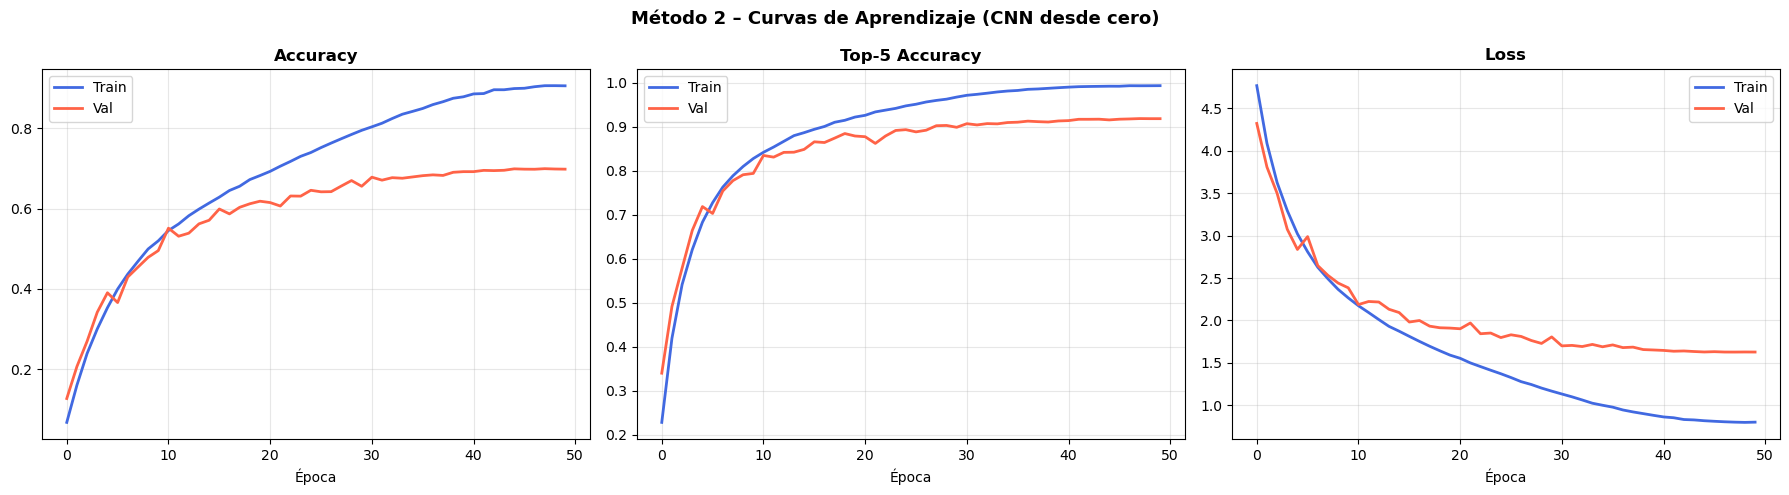

Figura guardada: curvas_metodo2.png


In [20]:
# ── Evaluación final Método 2 – sobre TEST SET (nunca visto durante entreno) ──
loss_c, acc_c, top5_c = model_custom.evaluate(ds_test_custom, verbose=0)
print(f'=== Resultados finales – Método 2 (CNN desde cero) ===')
print(f'  [Evaluado sobre test set, no visto durante entrenamiento]')
print(f'  Top-1 Accuracy : {acc_c*100:.2f}%')
print(f'  Top-5 Accuracy : {top5_c*100:.2f}%')
print(f'  Loss           : {loss_c:.4f}')
print(f'  Tiempo total   : {t_custom/60:.1f} min')

# ── Curvas de aprendizaje Método 2 ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Método 2 – Curvas de Aprendizaje (CNN desde cero)', 
             fontsize=13, fontweight='bold')

for ax, (train_key, val_key, title) in zip(axes, metrics):
    ax.plot(hist_custom.history[train_key], label='Train', color='royalblue', linewidth=2)
    ax.plot(hist_custom.history[val_key],   label='Val',   color='tomato',    linewidth=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Época'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_metodo2.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: curvas_metodo2.png')

---
## 6. Comparación de Resultados <a id='6'></a>

Con ambos modelos entrenados y evaluados sobre el mismo test set, podemos compararlos de forma justa. Veremos las métricas globales, cómo se comportan por tipo de objeto y en qué imágenes concretas falla cada uno — porque los números solos no siempre cuentan la historia completa.

### 6.1 Tabla comparativa final

In [21]:
# ── Tabla resumen de métricas ────────────────────────────────────────────────
import pandas as pd

# Número de parámetros
params_tl     = sum(np.prod(v.shape) for v in model_tl.weights)
params_custom = sum(np.prod(v.shape) for v in model_custom.weights)

results = pd.DataFrame({
    'Modelo':            [f'Transfer Learning ({winner_name})', 'CNN desde cero (CustomResNet)'],
    'Top-1 Acc (%)':     [round(acc_tl2*100, 2),  round(acc_c*100, 2)],
    'Top-5 Acc (%)':     [round(top5_tl2*100, 2), round(top5_c*100, 2)],
    'Loss':              [round(loss_tl2, 4),      round(loss_c, 4)],
    'Parámetros (M)':    [round(params_tl/1e6, 2), round(params_custom/1e6, 2)],
    'Tiempo (min)':      [round((t_tl1+t_tl2)/60, 1), round(t_custom/60, 1)]
})

print('=== TABLA COMPARATIVA ===')
print(results.to_string(index=False))

=== TABLA COMPARATIVA ===
                            Modelo  Top-1 Acc (%)  Top-5 Acc (%)   Loss  Parámetros (M)  Tiempo (min)
Transfer Learning (EfficientNetB0)          69.83          92.45 1.0821            4.76         105.9
     CNN desde cero (CustomResNet)          70.01          91.15 1.6471            4.42         243.1


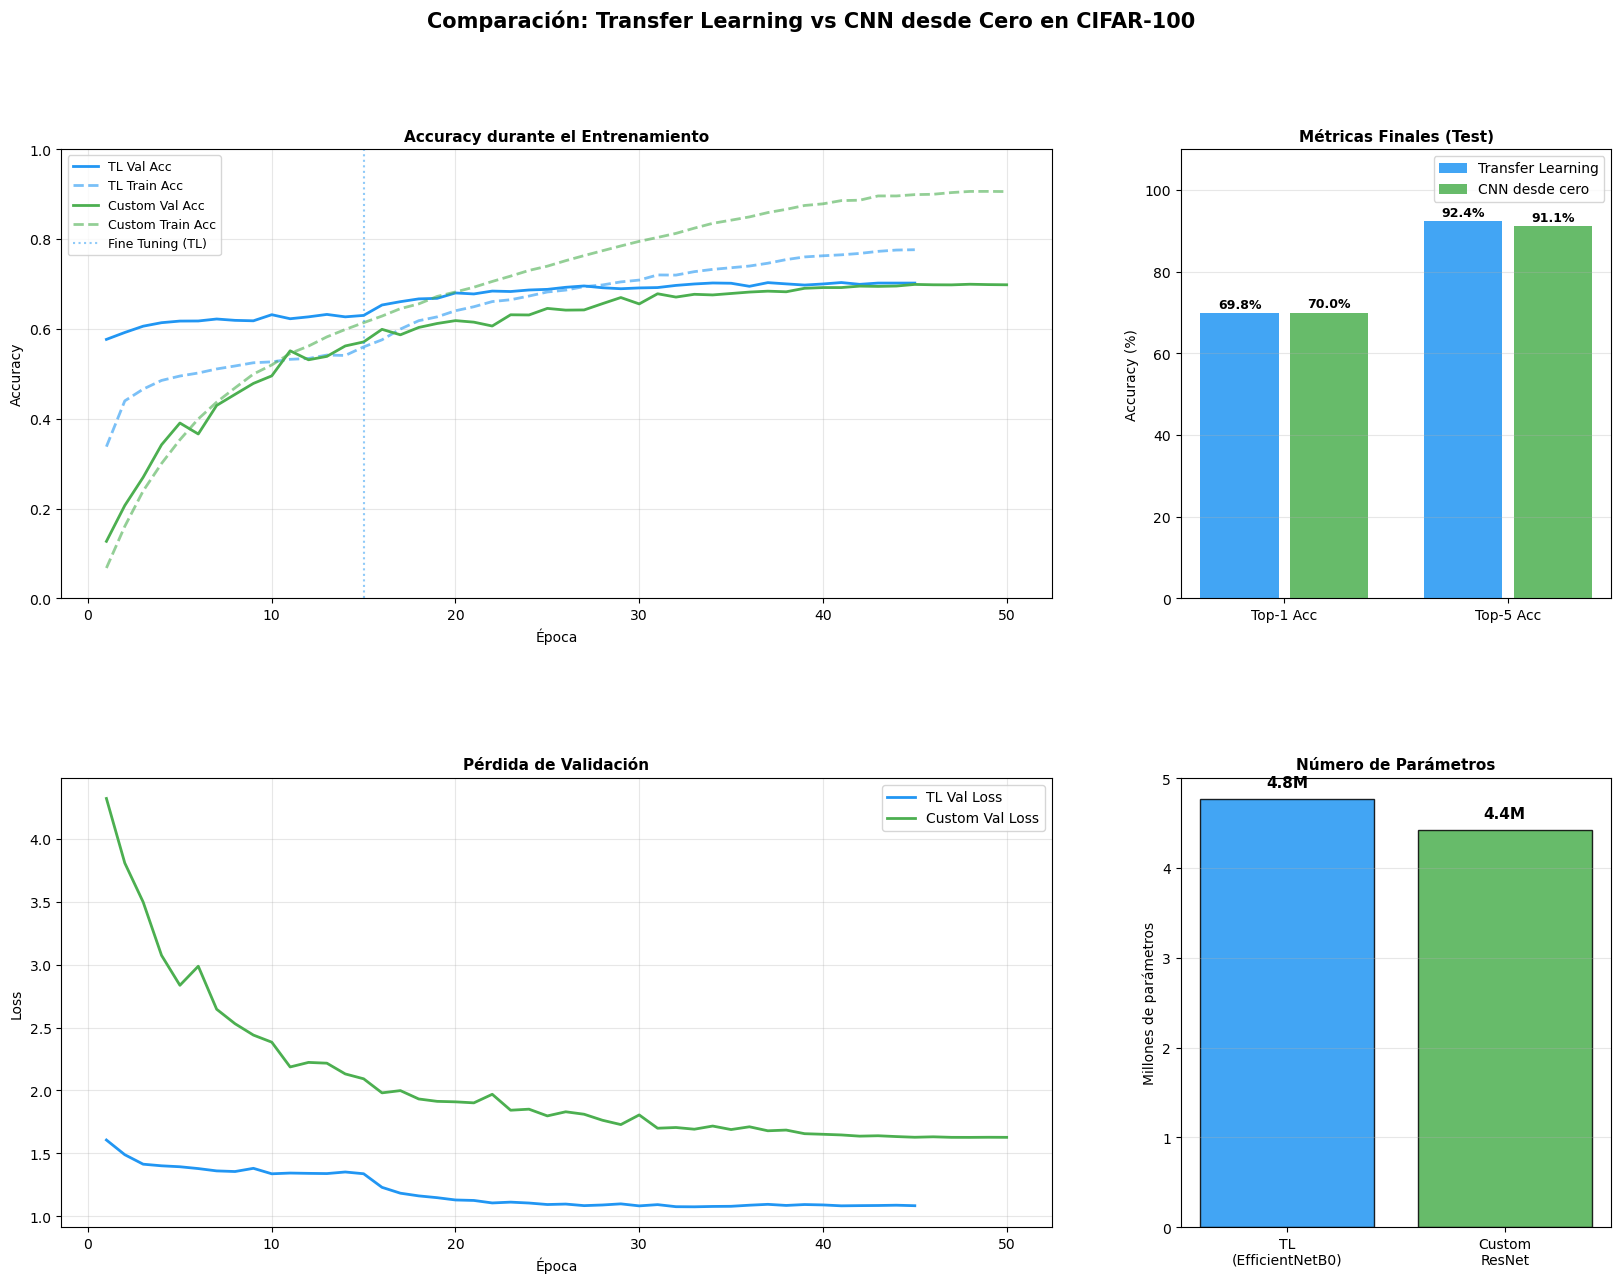

Figura guardada: comparacion_metodos.png


In [22]:
# ── Gráficos comparativos ────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Comparación: Transfer Learning vs CNN desde Cero en CIFAR-100', 
             fontsize=15, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)

colors_m1 = ('#2196F3', '#F44336')  # azul/rojo para TL
colors_m2 = ('#4CAF50', '#FF9800')  # verde/naranja para custom

# ── 1. Accuracy de validación comparada ──
ax1 = fig.add_subplot(gs[0, 0:2])
ep_tl = range(1, len(hist_tl_combined['val_accuracy']) + 1)
ep_cu = range(1, len(hist_custom.history['val_accuracy']) + 1)
ax1.plot(ep_tl, hist_tl_combined['val_accuracy'],   label='TL Val Acc',     color='#2196F3', linewidth=2)
ax1.plot(ep_tl, hist_tl_combined['accuracy'],        label='TL Train Acc',   color='#2196F3', linewidth=2, linestyle='--', alpha=0.6)
ax1.plot(ep_cu, hist_custom.history['val_accuracy'], label='Custom Val Acc', color='#4CAF50', linewidth=2)
ax1.plot(ep_cu, hist_custom.history['accuracy'],     label='Custom Train Acc',color='#4CAF50',linewidth=2, linestyle='--', alpha=0.6)
ax1.axvline(split_epoch, color='#2196F3', linestyle=':', alpha=0.5, label='Fine Tuning (TL)')
ax1.set_title('Accuracy durante el Entrenamiento', fontweight='bold', fontsize=11)
ax1.set_xlabel('Época'); ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# ── 2. Barras de métricas finales ──
ax2 = fig.add_subplot(gs[0, 2])
metrics_names = ['Top-1 Acc', 'Top-5 Acc']
vals_tl  = [acc_tl2*100,  top5_tl2*100]
vals_cu  = [acc_c*100,    top5_c*100]
x = np.arange(len(metrics_names))
bars1 = ax2.bar(x - 0.2, vals_tl, 0.35, label='Transfer Learning', color='#2196F3', alpha=0.85)
bars2 = ax2.bar(x + 0.2, vals_cu, 0.35, label='CNN desde cero',    color='#4CAF50', alpha=0.85)
for bar in bars1 + bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(metrics_names)
ax2.set_ylabel('Accuracy (%)'); ax2.set_ylim(0, 110)
ax2.set_title('Métricas Finales (Test)', fontweight='bold', fontsize=11)
ax2.legend(); ax2.grid(True, alpha=0.3, axis='y')

# ── 3. Loss comparado ──
ax3 = fig.add_subplot(gs[1, 0:2])
ax3.plot(ep_tl, hist_tl_combined['val_loss'],   label='TL Val Loss',     color='#2196F3', linewidth=2)
ax3.plot(ep_cu, hist_custom.history['val_loss'], label='Custom Val Loss', color='#4CAF50', linewidth=2)
ax3.set_title('Pérdida de Validación', fontweight='bold', fontsize=11)
ax3.set_xlabel('Época'); ax3.set_ylabel('Loss')
ax3.legend(); ax3.grid(True, alpha=0.3)

# ── 4. Comparativa de parámetros y tiempo ──
ax4 = fig.add_subplot(gs[1, 2])
params_M = [params_tl/1e6, params_custom/1e6]
bar_colors = ['#2196F3', '#4CAF50']
bars = ax4.bar(['TL\n(EfficientNetB0)', 'Custom\nResNet'], params_M, color=bar_colors, alpha=0.85, edgecolor='black')
for bar, val in zip(bars, params_M):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}M', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax4.set_title('Número de Parámetros', fontweight='bold', fontsize=11)
ax4.set_ylabel('Millones de parámetros')
ax4.grid(True, alpha=0.3, axis='y')

plt.savefig('comparacion_metodos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: comparacion_metodos.png')

### 6.2 Análisis de errores

In [23]:
# ── Análisis de errores: Confusion Matrix (superclases) ──────────────────────
# Las 100 clases se agrupan en 20 superclases para mejor visualización

SUPERCLASSES = [
    'acuáticos', 'flores', 'fruta/verdura', 'electrónica', 'muebles',
    'insectos', 'carnívorosmedios', 'medios externoss', 'no-insectos', 'personas',
    'reptiles', 'pequeños mamíferos', 'árboles', 'vehículos1', 'vehículos2',
    'grandes carnívoros', 'grandes herbívoros', 'objetos hogar', 'escenas naturales', 'contenedores'
]

# Mapeo: clase fina (0-99) → superclase (0-19)
# En CIFAR-100, las superclases se pueden cargar directamente
(_, y_train_coarse_raw), (_, y_test_coarse_raw) = keras.datasets.cifar100.load_data(label_mode='coarse')

# Predicciones de ambos modelos
print('Generando predicciones...')
y_pred_tl  = model_tl.predict(ds_test_tl,     verbose=0)
y_pred_cu  = model_custom.predict(ds_test_custom, verbose=0)

y_pred_tl_labels  = np.argmax(y_pred_tl,  axis=1)
y_pred_cu_labels  = np.argmax(y_pred_cu,  axis=1)
y_true_labels     = y_test_raw.flatten()

# Top-5 accuracy manual
def top_k_accuracy(y_true, y_pred_proba, k=5):
    top_k = np.argsort(y_pred_proba, axis=1)[:, -k:]
    return np.mean([y_true[i] in top_k[i] for i in range(len(y_true))])

print(f'\nVerificación Top-5:')
print(f'  Transfer Learning : {top_k_accuracy(y_true_labels, y_pred_tl)*100:.2f}%')
print(f'  CNN desde cero    : {top_k_accuracy(y_true_labels, y_pred_cu)*100:.2f}%')

Generando predicciones...


2026-04-28 01:47:19.026102: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.



Verificación Top-5:
  Transfer Learning : 92.45%
  CNN desde cero    : 91.15%


### 6.3 Análisis por Superclase

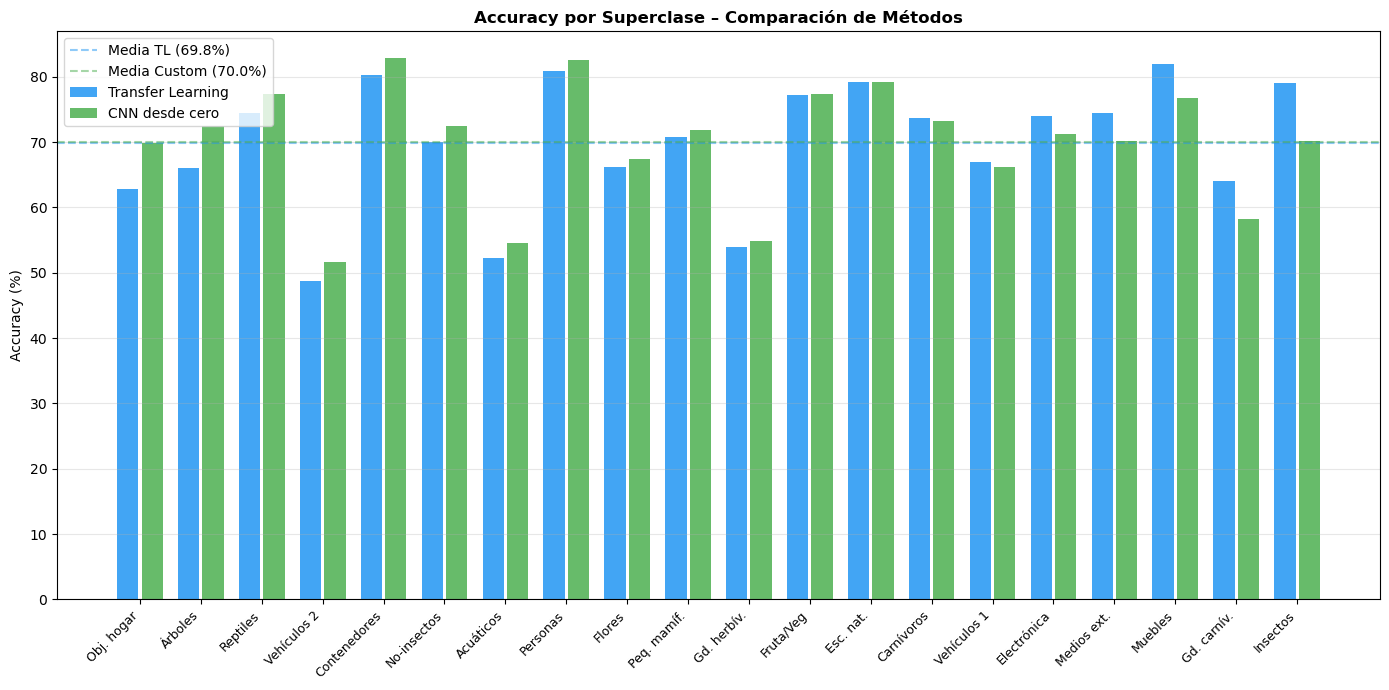

Figura guardada: acc_por_superclase.png


In [24]:
# ── Análisis por superclase ───────────────────────────────────────────────────
SUPERCLASS_NAMES = [
    'Acuáticos', 'Flores', 'Fruta/Veg', 'Electrónica', 'Muebles',
    'Insectos', 'Carnívoros', 'Medios ext.', 'No-insectos', 'Personas',
    'Reptiles', 'Peq. mamíf.', 'Árboles', 'Vehículos 1', 'Vehículos 2',
    'Gd. carnív.', 'Gd. herbív.', 'Obj. hogar', 'Esc. nat.', 'Contenedores'
]

# Accuracy por superclase
def acc_by_superclass(y_true_fine, y_coarse, y_pred_fine, n_superclasses=20):
    accs = []
    for sc in range(n_superclasses):
        mask = (y_coarse.flatten() == sc)
        if mask.sum() == 0:
            accs.append(0)
        else:
            accs.append((y_true_fine[mask] == y_pred_fine[mask]).mean())
    return np.array(accs)

acc_sc_tl = acc_by_superclass(y_true_labels, y_test_coarse_raw, y_pred_tl_labels)
acc_sc_cu = acc_by_superclass(y_true_labels, y_test_coarse_raw, y_pred_cu_labels)

# Ordenar por diferencia
diff = acc_sc_tl - acc_sc_cu
order = np.argsort(diff)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(20)
ax.bar(x - 0.2, acc_sc_tl[order]*100, 0.35, label='Transfer Learning', color='#2196F3', alpha=0.85)
ax.bar(x + 0.2, acc_sc_cu[order]*100, 0.35, label='CNN desde cero',    color='#4CAF50', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([SUPERCLASS_NAMES[i] for i in order], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy por Superclase – Comparación de Métodos', fontweight='bold', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
ax.axhline(acc_tl2*100, color='#2196F3', linestyle='--', alpha=0.5, label=f'Media TL ({acc_tl2*100:.1f}%)')
ax.axhline(acc_c*100,   color='#4CAF50', linestyle='--', alpha=0.5, label=f'Media Custom ({acc_c*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.savefig('acc_por_superclase.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: acc_por_superclase.png')

### 6.4 Muestras mal clasificadas


Errores Transfer Learning    : 3017 (30.2%)
Errores CNN desde cero       : 2999 (30.0%)
Errores compartidos (ambos)  : 1794 (17.9%)
Solo TL falla                : 1223 imágenes
Solo CNN falla               : 1205 imágenes


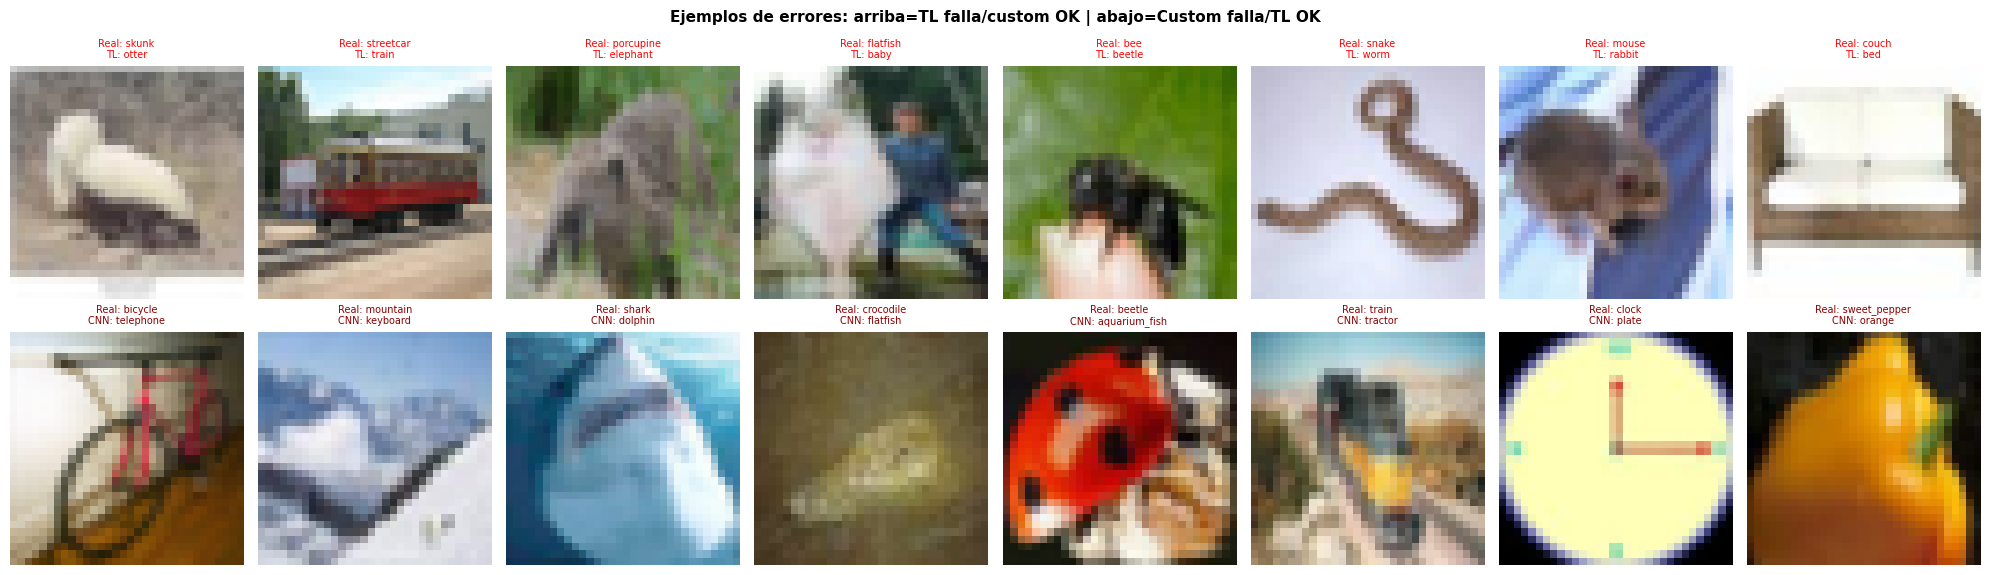

Figura guardada: errores_clasificacion.png


In [25]:
# ── Análisis de muestras mal clasificadas ─────────────────────────────────────
wrong_tl  = np.where(y_pred_tl_labels  != y_true_labels)[0]
wrong_cu  = np.where(y_pred_cu_labels  != y_true_labels)[0]
wrong_both = np.intersect1d(wrong_tl, wrong_cu)  # errores compartidos

print(f'Errores Transfer Learning    : {len(wrong_tl)} ({100*len(wrong_tl)/len(y_true_labels):.1f}%)')
print(f'Errores CNN desde cero       : {len(wrong_cu)} ({100*len(wrong_cu)/len(y_true_labels):.1f}%)')
print(f'Errores compartidos (ambos)  : {len(wrong_both)} ({100*len(wrong_both)/len(y_true_labels):.1f}%)')
print(f'Solo TL falla                : {len(wrong_tl)-len(wrong_both)} imágenes')
print(f'Solo CNN falla               : {len(wrong_cu)-len(wrong_both)} imágenes')

# Visualizar ejemplos donde uno acierta y el otro falla
only_tl_wrong = np.setdiff1d(wrong_tl, wrong_cu)   # TL falla, custom acierta
only_cu_wrong = np.setdiff1d(wrong_cu, wrong_tl)   # custom falla, TL acierta

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('Ejemplos de errores: arriba=TL falla/custom OK | abajo=Custom falla/TL OK', 
             fontsize=11, fontweight='bold')

for col, idx in enumerate(only_tl_wrong[:8]):
    ax = axes[0, col]
    ax.imshow(x_test_raw[idx])
    true_cls  = FINE_LABELS[y_true_labels[idx]]
    pred_tl   = FINE_LABELS[y_pred_tl_labels[idx]]
    ax.set_title(f'Real: {true_cls}\nTL: {pred_tl}', fontsize=7, color='red')
    ax.axis('off')

for col, idx in enumerate(only_cu_wrong[:8]):
    ax = axes[1, col]
    ax.imshow(x_test_raw[idx])
    true_cls  = FINE_LABELS[y_true_labels[idx]]
    pred_cu   = FINE_LABELS[y_pred_cu_labels[idx]]
    ax.set_title(f'Real: {true_cls}\nCNN: {pred_cu}', fontsize=7, color='darkred')
    ax.axis('off')

plt.tight_layout()
plt.savefig('errores_clasificacion.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: errores_clasificacion.png')

In [26]:
# ── Tabla final completa ──────────────────────────────────────────────────────
print('\n' + '='*70)
print(' RESUMEN COMPARATIVO FINAL '.center(70, '='))
print('='*70)
print(f"{'Métrica':<30} {'Transfer Learning':>20} {'CNN desde cero':>16}")
print('-'*70)
print(f"{'Top-1 Accuracy (Test)':<30} {acc_tl2*100:>18.2f}% {acc_c*100:>14.2f}%")
print(f"{'Top-5 Accuracy (Test)':<30} {top5_tl2*100:>18.2f}% {top5_c*100:>14.2f}%")
print(f"{'Loss (Test)':<30} {loss_tl2:>20.4f} {loss_c:>16.4f}")
print(f"{'Parámetros totales':<30} {params_tl/1e6:>17.2f}M {params_custom/1e6:>13.2f}M")
print(f"{'Tiempo entrenamiento':<30} {(t_tl1+t_tl2)/60:>17.1f}min {t_custom/60:>11.1f}min")
print(f"{'Errores en test':<30} {len(wrong_tl):>20,} {len(wrong_cu):>16,}")
print('='*70)

ganador = 'Transfer Learning' if acc_tl2 > acc_c else 'CNN desde cero'
mejora  = abs(acc_tl2 - acc_c) * 100
print(f'\n→ Mejor modelo: {ganador} (+{mejora:.2f}% de accuracy)')


===================== RESUMEN COMPARATIVO FINAL ======================
Métrica                           Transfer Learning   CNN desde cero
----------------------------------------------------------------------
Top-1 Accuracy (Test)                       69.83%          70.01%
Top-5 Accuracy (Test)                       92.45%          91.15%
Loss (Test)                                  1.0821           1.6471
Parámetros totales                          4.76M          4.42M
Tiempo entrenamiento                       105.9min       243.1min
Errores en test                               3,017            2,999

→ Mejor modelo: CNN desde cero (+0.18% de accuracy)


## 7. Conclusiones




### 7.1 ¿Qué nos dicen los resultados?

Los dos métodos han llegado prácticamente al mismo sitio en Top-1 Accuracy (70.01% vs 69.83%), pero con diferencias importantes en otras métricas. El camino ha sido muy distinto y eso revela las fortalezas y debilidades de cada enfoque.

| Aspecto | Transfer Learning (EfficientNetB0) | CNN desde cero (CustomResNet) |
|---------|-------------------|----------------|
| **Top-1 Accuracy (Test)** | 69.83% | ✅ 70.01% |
| **Top-5 Accuracy (Test)** | ✅ 92.45% | 91.15% |
| **Loss (Test)** | ✅ 1.0821 | ⚠️ 1.6471 |
| **Parámetros** | 4.76M | ✅ 4.42M |
| **Tiempo de entrenamiento** | ✅ 105.9 min | ❌ 243.1 min |
| **Errores en test** | 3.017 (30.2%) | ✅ 2.999 (30.0%) |
| **Velocidad de convergencia** | ✅ Rápida — ya sabe ver | ❌ Necesita más épocas |
| **Datos necesarios** | ✅ Funciona bien con pocos datos | ❌ Cuantos más datos, mejor |
| **Libertad de diseño** | ❌ Limitada por el backbone | ✅ Total — controlamos cada capa |

El resultado más llamativo es el **empate técnico en Top-1** (0.18% de diferencia), pero con una **diferencia de coste enorme**: la CNN custom tardó 2.3 veces más (243 vs 106 min). En términos de eficiencia, el Transfer Learning es claramente superior. Esto es muy relevante en escenarios empresariales. Con Transfer Learning obtenemos un ahorro significativo.

La diferencia de Loss (1.08 vs 1.65) indica que el modelo de Transfer Learning está mejor calibrado — es más seguro cuando acierta y menos confiado cuando falla.

### 7.2 El reto específico de CIFAR-100

El Transfer Learning tiene una desventaja concreta en este dataset: las imágenes de 32×32 son muy diferentes a las de ImageNet (224×224). Escalarlas a 96×96 introduce artefactos y los patrones que los modelos aprendieron (texturas finas, bordes detallados en alta resolución) transfieren peor. Con 100 clases en lugar de las 10 de CIFAR-10.

A pesar de ese lastre, EfficientNetB0 igualó prácticamente a la CNN custom, lo que habla bien del poder del Transfer Learning incluso en condiciones desfavorables.

En la comparación de arquitecturas, EfficientNetB0 superó claramente a MobileNetV2 en Feature Extraction (63.22% vs 54.72%), confirmando que es la elección correcta para este dataset.

### 7.3 Las técnicas que más impacto tuvieron

1. **Batch Normalization** — Clave en la CNN custom: estabiliza el entrenamiento y permite usar LR más altos sin que explote.
2. **Conexiones residuales** — Permiten entrenar más profundo sin que el gradiente desaparezca por el camino.
3. **Cosine Decay LR** — Mejor que reducción abrupta: la bajada suave al final permite refinar los pesos con precisión.
4. **Data Augmentation** — Imprescindible. Con solo 500 imágenes por clase sin augmentation los modelos memorizarían.
5. **Fine Tuning selectivo** — Descongelar solo las últimas 30 capas del backbone (46.1% de parámetros entrenables), no todo, fue esencial para no sobreajustar.

### 7.4 Análisis de errores complementarios

Un dato especialmente interesante: de los errores totales, **solo el 17.9% son compartidos por ambos modelos**. El 12.2% restante lo falla solo uno de los dos:

- Solo TL falla: 1.223 imágenes
- Solo CNN falla: 1.205 imágenes

Esto sugiere que los modelos han aprendido representaciones distintas del mismo problema.

### 7.5 Posibles mejoras

- **Método 1:** Probar *progressive fine tuning* descongelando el backbone por etapas (p. ej. últimas 10 → 20 → 30 capas), entrenando brevemente en cada fase, para una adaptación más gradual y controlada que reduzca el riesgo de sobreajuste. También se podría explorar `EfficientNetV2` o un Vision Transformer (ViT); usar `MixUp` o `CutMix` como augmentation.
- **Método 2:** Añadir bloques Squeeze-and-Excitation o Label Smoothing para mejorar la calibración de las predicciones (la loss de 1.65 vs 1.08 del TL indica margen de mejora).